# Big title

## Imports

In [35]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict

from TherMIFASOL.core.variables.GlobalVariables import BASE_DIR
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer
)

In [21]:
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    BASE_DIR = Path().resolve().parents[2]

## Devices

### Pyrometer

#### First campaign

In [25]:
list_BB_temperature_C = [600, 700, 800, 900, 1000, 1100, 1200]
INFO = {}

for T_BB_C in list_BB_temperature_C:
    str_data_file_name = os.path.join(
        BASE_DIR, f"data/calibration/pyrometer/BB_cavity/CSVfiles/CN{T_BB_C}.csv"
        )
    INFO[T_BB_C] = collect_data_pyrometer(csv_path=str_data_file_name)

In [32]:
for T_BB_C in list_BB_temperature_C:
    print(INFO[T_BB_C]['nb data'], f"{INFO[T_BB_C]['temps acquisition']:4f}", f"{INFO[T_BB_C]['FPS mean']:.4f}")

25719 3.347971 7884.3845
34614 4.491107 7881.7072
48235 6.187724 7845.4349
49555 6.462249 7883.7572
38881 5.029695 7831.2778
25061 3.239447 7886.7528
27741 3.550435 7828.2079


In [37]:
keys_mean = {
    'T_2C': 'array temp2C',
    'T_K1': 'array tempK1',
    'T_K2': 'array tempK2',
    'my_T_2C': 'array MAtemp2C',
    'my_eps': 'array MAemissivity',
    'T_device': 'array tempDevice'
}

mean_values = defaultdict(list)
std_values = defaultdict(list)

for T_BB_C in list_BB_temperature_C:
    for key, data_key in keys_mean.items():
        values = INFO[T_BB_C][data_key]
        mean_values[key].append(np.mean(values))
        std_values[key].append(np.std(values))

# Conversion en np.array
for key in keys_mean:
    mean_values[key] = np.array(mean_values[key])
    std_values[key] = np.array(std_values[key])

array_BB_temperature_C = np.array(list_BB_temperature_C)

$\xi_3(T) = \frac{|T_{\text{BB}} - T_{\text{pyro}}|}{T_{\text{BB}}} \times 100$


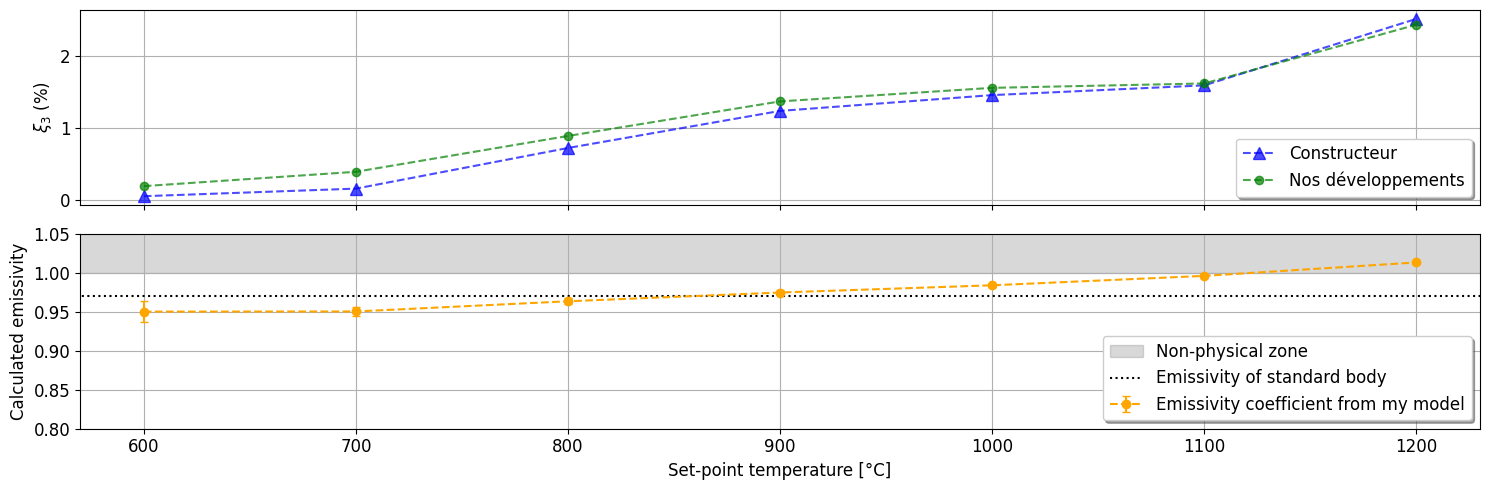

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

ax1.plot(array_BB_temperature_C, 100*np.abs(mean_values['T_2C']-array_BB_temperature_C)/array_BB_temperature_C, 'b^--', ms=8, alpha=0.7, label=f'Constructeur')
ax1.plot(array_BB_temperature_C, 100*np.abs(mean_values['my_T_2C']-array_BB_temperature_C)/array_BB_temperature_C, 'go--', alpha=0.7, label=f'Nos développements')
ax1.set_ylabel(r"$\xi_3$ (%)", fontsize=12)
ax1.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
ax1.set_xlim(570, 1230)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(True)

EPS_CN = 0.97
ax2.fill_between([300, 1700], 1, 1.5, color='gray', alpha=0.3, label='Non-physical zone')
ax2.hlines(y=EPS_CN, xmin=300, xmax=1700, color='k', ls=':', label='Emissivity of standard body')

ax2.errorbar(array_BB_temperature_C, mean_values['my_eps'], yerr=std_values['my_eps'], 
             color='orange', fmt='o--', capsize=3, label='Emissivity coefficient from my model'
             )
ax2.set_xlabel('Set-point temperature [°C]', fontsize=12)
ax2.set_ylabel('Calculated emissivity', fontsize=12)
ax2.set_ylim(0.8, 1.05)
ax2.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True)

fig.tight_layout()
plt.show()